# Assignment 2

# Problem and Motivation
In the previous exercise we tried to find a global optimimum to our optimization problem consisting of finding the optimal parameter to get a NSE close to 1. Now, we want to investigate the local sensitivity of the obtained parameters. In fact, under the assumption that we found a global optimum we want to perturbe each parameter individually and examine the change in the NSE value. This analysis is helpful to determine which small change in parameters causes the most radical change in the objective function value. WIth this, one could deduce which parameters are the most sensitive in the sense that they matter the most in our model fit for our given catchment.

Parameter uncertainty quantification is useful locally as our optimization problem was in large dimensions. Due to the model complexity, in combination with the stochastic solver being the Differential Evolution, we can use the following work to not only determine if we found indeed a global optimum, but also tell which parameters could be neglected in further analysis. However, one should be aware of the major shortcoming of the approach chosen, which will be depicted in the upcoming section

# Theory
Local sensitivity analysis is straight forward: One fixes the parameter vector and only changes one parameter at a time. The perturbation consists of iterating over different possible parameter values where the middle of the interval is the obtained parameter value from assignment 1. In our case we considered an interval of +/- 20% around our middle point. One should be aware that for the snow threshold temperature "snw_att" we chose an interval of +/- 1 degree celsius due to the nature of the parameter being a temperature. In each iteration, one computes the NSE or 1-NSE and plots the parameter range against the obtained OFVs. Ideally, one should obtain a parabola or another smooth function with our obtained parameter being the minimum. 

From a mathematical point of view, local sensitivity analysis is equivalent to analysing the partial derivative wrt. a parameter of of objective function. More precisely, the small perturbations around our obtained (optimal) parameter correspond to the partial derivatives around those point. This also explains the major shortcoming of this approach: One assumes to have found the gloabl optimum and that taking partial derivatives is possible. In our case, this is clearly not fullfilled. Furthermore, varying each parameter individually and independently doesn't take into account any main effects or even interactions. The local sensitivty analysis can't differntiate between a local and a global optimum - f you are in a "local hole," your sensitivity analysis only tells you about that specific hole, not the whole landscape. We will address those issues in the upcoming exercise.

To rank the local sensitivity, for each parameter we compute the maximum difference in our OFVs in our given range.

# Implementation

The implemention looks as follow:

In [ ]:
#---------------------------------------------------------------------------------
# Sensitivity Analysis Loop
#---------------------------------------------------------------------------------
# Container initialization
results = {}
spaces = {}
min_value = [] # init. min and max container for ranking later on
max_value = []
diff = []

# Define the bounds to check for
BOUNDS = [
    (0.00, 0.00),   # snw_dth  (fixed 0)
    (-2.0, 3.0),    # snw_att
    (0.00, 3.00),   # snw_pmf
    (0.00, 10.0),   # snw_amf

    (0.00, 100.0),  # sl0_dth
    (5.00, 700.0),  # sl0_pwp
    (100.0, 700.0), # sl0_fcy
    (0.01, 10.0),   # sl0_bt0

    (0.00, 20.0),   # urr_dth
    (0.00, 100.0),  # lrr_dth

    (0.00, 1.00),   # urr_wsr
    (0.00, 1.00),   # urr_ulc
    (0.00, 200.0),  # urr_tdh
    (0.01, 1.00),   # urr_tdr
    (0.00, 1.00),   # urr_ndr
    (0.00, 1.00),   # urr_uct

    (0.00, 1.00),   # lrr_dre
    (0.00, 1.00),   # lrr_lct
]

# Now start the foor loop to run over each parameter set
for j in tqdm.tqdm(range(len(PARAM_NAMES))):
    index = j
    name = PARAM_NAMES[j]
    OptimalValue = OptimalParameterDE[j]
    # No relative but absolute change for TT
    if name != "snw_att":
       lower = OptimalValue * 0.8
       upper = OptimalValue * 1.2
    else: # absoulte change for TT
       lower = OptimalValue - 1
       upper = OptimalValue + 1

    # Check if bounds are violated
    lowerbound, upperbound = BOUNDS[index]

    if upper > upperbound:
       upper = upperbound

    if lower < lowerbound:
       lower = lowerbound

    # Loop over the relative changes
    parameterspace = np.linspace(lower, upper, num=200, endpoint=True)
    spaces[name] = parameterspace

    ofv_values = []  # Das wird nicht klappen
    for i in range(len(parameterspace)):
        parameter_value = parameterspace[i]
        # Set the parameter value in the model
        params = OptimalParameterDE.copy()
        params[index] = parameter_value
        # Evaluate the objective function
        ofv, metrics, sim = objective_function(params, m0, diso)
        ofv_values.append(ofv)
    
    results[name] = ofv_values
    mini = round(np.min(ofv_values),4)
    min_value.append(mini)
    maxi = round(np.max(ofv_values),4)
    max_value.append(maxi)
    diff.append(round(np.abs(np.max(ofv_values)- np.min(ofv_values)),4))

# Results

Our run with an interval of +/- 20% resulted in the following ranking:

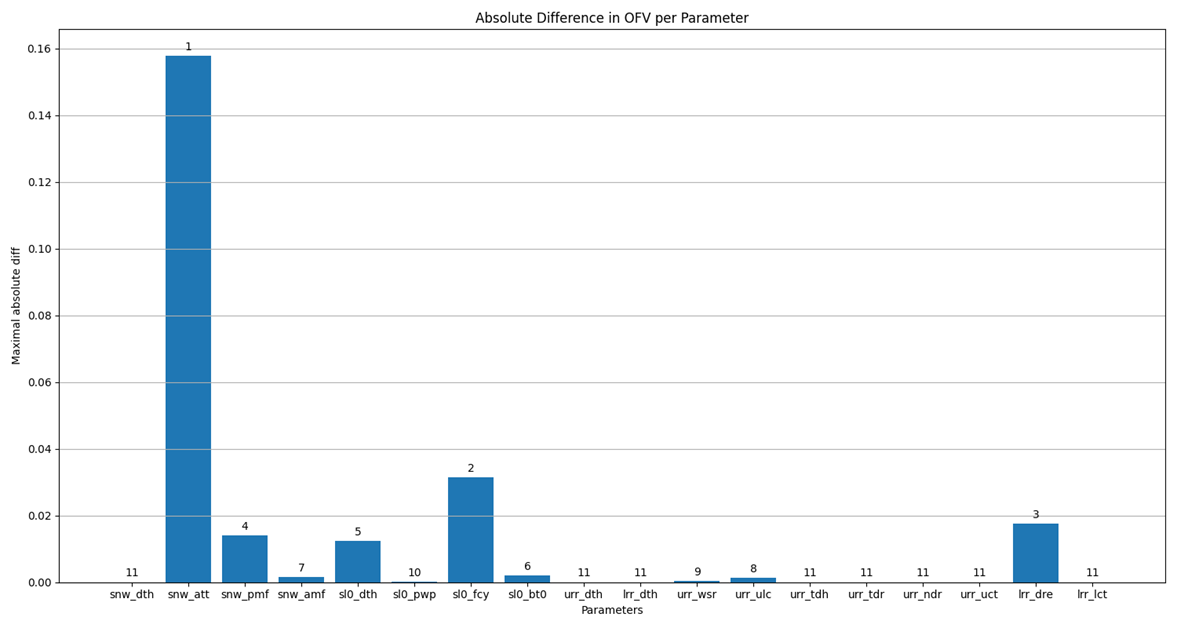

The exact differences are depicted in the following table:

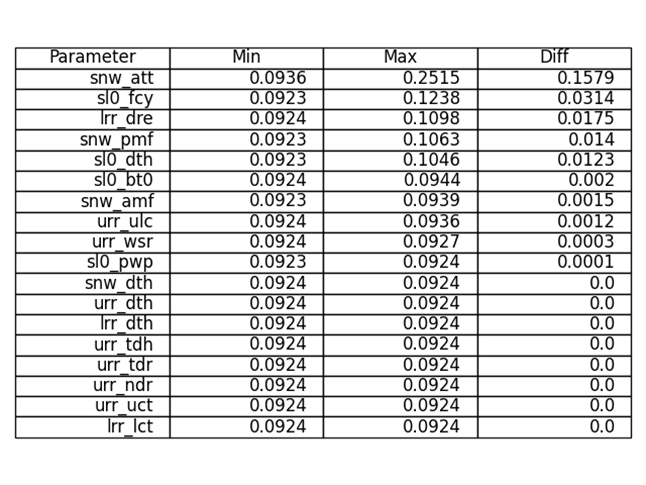